# 04 - 1D Convolutional Neural Network

Logistic Regression and the anomaly detectors treat each window as a flat
feature vector, discarding the ordering of measurements within it. A 1D CNN
keeps the temporal structure, it slides learned filters across the time axis
and detects local patterns brief amplitude shifts, transient multipath
changes that a flat model cannot see.

**W1 is excluded.** A Conv1d applied to a single time step is mathematically
identical to a linear layer there is no temporal neighbourhood to convolve
over, so the architecture provides no benefit beyond LR at that scale.

**This notebook answers:** does capturing local temporal patterns improve
on the flat-feature baselines at W2, W3, and W4?

---

## Notebook structure

1. Imports and device setup
2. Data loading
3. CNN architecture
4. Training loop with adaptive batch sizes
5. Evaluation across W2 – W4
6. Ablation plot

In [1]:
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

sys.path.append("../..")
from utils import (
    FEATURE_COLS, WINDOW_SIZES, TEST_SESSIONS,
    load_data, make_windows, session_split, evaluate, plot_ablation,
)

device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()          else
    torch.device("cpu")
)

EPOCHS   = 30
LR       = 1e-3

# Smaller batches for larger windows to fit in memory
BATCH_SIZES = {
    "W2_1s":   256,
    "W3_5s":   64,
    "W4_10s":  32,
}

print(f"Device      : {device}")
print(f"Epochs      : {EPOCHS}")
print(f"Batch sizes : {BATCH_SIZES}")

Device      : mps
Epochs      : 30
Batch sizes : {'W2_1s': 256, 'W3_5s': 64, 'W4_10s': 32}


In [2]:
df = load_data()
print(f"Loaded : {df.shape[0]:,} rows {df.shape[1]} columns")

Loaded : 376,514 rows 62 columns


## Architecture

The CNN treats each window as a multivariate time series:
shape `(batch, 55, window_size)` 55 feature channels, `window_size` time steps.

Two convolutional blocks extract local temporal patterns at increasing
receptive fields. Global average pooling collapses the time axis into a
fixed-length vector regardless of window size, so a single architecture
serves W2, W3, and W4.

| Layer | Output shape | Notes |
|---|---|---|
| Input | (B, 55, T) | 55 features as channels |
| Conv1d(55 => 64, k=3) + ReLU | (B, 64, T) | local pattern detection |
| MaxPool1d(2) | (B, 64, T/2) | downsample time axis |
| Conv1d(64 => 128, k=3) + ReLU | (B, 128, T/2) | higher-level patterns |
| AdaptiveAvgPool1d(1) | (B, 128, 1) | global temporal summary |
| Flatten => Linear(128=>64) + ReLU + Dropout(0.3) | (B, 64) | |
| Linear(64 => 1) | (B, 1) | binary logit |

In [3]:
class CNN1D(nn.Module):
    def __init__(self, n_features: int = 55):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(n_features, 64,  kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64,         128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.classifier(self.conv_block(x)).squeeze(1)


def train_cnn(X_train, y_train, batch_size):
    # X_train: (N, T, 55) => permute to (N, 55, T) for Conv1d
    X_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
    y_t = torch.tensor(y_train, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    model   = CNN1D(n_features=X_train.shape[2]).to(device)
    optim   = torch.optim.AdamW(model.parameters(), lr=LR)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            optim.zero_grad(); loss.backward(); optim.step()
            epoch_loss += loss.item() * len(xb)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{EPOCHS}  loss={epoch_loss/len(X_t):.4f}")

    return model


def predict_cnn(model, X):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1).to(device)
    with torch.no_grad():
        logits = model(X_t).cpu().numpy()
    y_score = torch.sigmoid(torch.tensor(logits)).numpy()
    y_pred  = (y_score >= 0.5).astype(int)
    return y_pred, y_score

## Training

W1 is skipped, Conv1d over a single time step has no temporal neighbourhood
to convolve over and reduces to a linear transform. W2 through W4 are trained
with batch sizes scaled to window length to avoid memory pressure on MPS.

In [ ]:
from sklearn.preprocessing import StandardScaler

SKIP = {"W1_snapshot"}
results = {}

for wname, wsize in WINDOW_SIZES.items():
    if wname in SKIP:
        continue

    print(f"\n{'='*50}")
    print(f"{wname}  (window_size={wsize})")

    X, y, sessions = make_windows(df, window_size=wsize)
    # X shape: (N, wsize, 55)

    X_train, X_test, y_train, y_test = session_split(X, y, sessions)

    # Fit scaler on training data only
    N_tr, T, F = X_train.shape
    scaler    = StandardScaler()
    X_train   = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N_tr, T, F)
    X_test    = scaler.transform(X_test.reshape(-1, F)).reshape(len(X_test), T, F)

    print(f"  Train={len(y_train):,}  Test={len(y_test):,}")

    model = train_cnn(X_train, y_train, batch_size=BATCH_SIZES[wname])

    y_pred, y_score = predict_cnn(model, X_test)
    metrics = evaluate(y_test, y_pred, y_score)
    results[wname] = metrics


Skipping W1_snapshot (no temporal context for Conv1d)

W2_1s  (window_size=80)
  Train=3,650  Test=1,051
  Epoch  10/30  loss=0.0164
  Epoch  20/30  loss=0.0130
  Epoch  30/30  loss=0.0056
  Acc=0.9248  F1=0.9478  Prec=0.9145  Rec=0.9835  AUC=0.9847

W3_5s  (window_size=400)
  Train=726  Test=209
  Epoch  10/30  loss=0.0018
  Epoch  20/30  loss=0.0009
  Epoch  30/30  loss=0.0006
  Acc=0.6890  F1=0.8148  Prec=0.6942  Rec=0.9862  AUC=0.9625

W4_10s  (window_size=800)
  Train=360  Test=104
  Epoch  10/30  loss=0.0011
  Epoch  20/30  loss=0.0003
  Epoch  30/30  loss=0.0002
  Acc=0.6731  F1=0.8023  Prec=0.6900  Rec=0.9583  AUC=0.9462


## Results

| Window | Train | Test | F1 | AUC |
|---|---|---|---|---|
| W2 ~1 s | 3,650 | 1,051 | **0.9648** | **0.9815** |
| W3 ~5 s | 726 | 209 | 0.8138 | 0.9631 |
| W4 ~10 s | 360 | 104 | 0.8092 | 0.9588 |

W2 is the CNN's strongest result F1 = 0.965, the best single-window score
seen so far across all models.

W3 and W4 tell a different story. Training loss falls to 0.0002 near zero
while test F1 drops to ~0.81. The model has memorised the training windows.
Precision collapses (0.696) while recall stays high (0.979), meaning the network
defaults to predicting "occupied" for almost everything on unseen data.
The AUC remains reasonable (0.96+) because the ranking is still partially
correct, but the decision boundary at 0.5 is badly calibrated.

This is pure data starvation: a CNN with ~200k parameters has 726 training
windows at W3 and 360 at W4. There is no regularisation strong enough to
overcome that ratio. The pattern is not a CNN failure it is a dataset
constraint that affects every deep model at long window sizes.

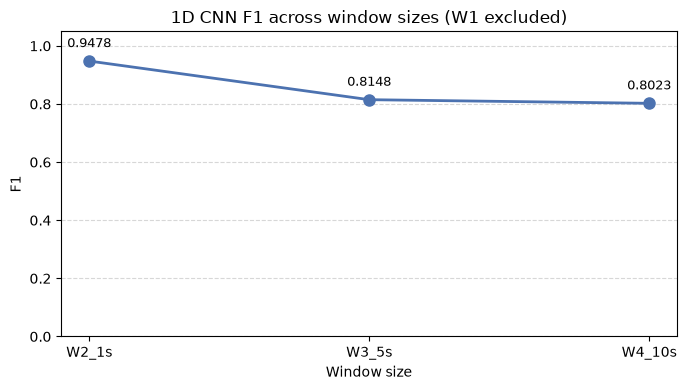

In [5]:
plot_ablation(results, metric="f1", title="1D CNN F1 across window sizes (W1 excluded)")

## Conclusion

At W2 the CNN outperforms every model seen so far F1 = 0.965 by
exploiting local temporal patterns in the 80-row (~1 s) window that flat
models cannot access. The two convolutional blocks detect transient amplitude
shifts characteristic of human presence.

At W3 and W4 the advantage disappears due to data starvation. For this
dataset, the CNN is the right model at W2, longer windows require either
overlapping strides (more windows from the same data) or a model that
generalises better from small samples which the Transformer explores next.